In [ ]:
%load_ext lab_black
%load_ext autoreload
%autoreload 2
%matplotlib inline

The lab_black extension is already loaded. To reload it, use:
  %reload_ext lab_black
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
import pickle
from typing import List
import numpy as np
from mne_connectivity.viz import plot_connectivity_circle
from mne.viz import circular_layout
import matplotlib.pyplot as plt
import numpy as np
import pickle


def create_hierarchy(states: List[str] = ["pre", "during", "post"]):
    hierarchy = {}
    fmin_fmax = [(1, 4), (4, 8), (8, 12), (13, 30), (30, 50), (1, 120)]
    conditions = range(1, 7)
    patients = range(2, 22)

    for fmin, fmax in fmin_fmax:
        filter_key = f"{fmin}_{fmax}"
        hierarchy[filter_key] = {}
        for condition in conditions:
            hierarchy[filter_key][condition] = {}
            for patient in patients:
                hierarchy[filter_key][condition][patient] = {}
                folder = f"D:\\neuro-closeloop-project\\vielight_close_loop\\clean_notebooks\\imcoh\\csd\\filters\\{filter_key}\\conditions\\{condition}\\results\\{patient}"
                if os.path.exists(folder) and os.listdir(folder):
                    for state in states:
                        pickle_file = os.path.join(
                            folder, f"{patient}_{state}_connectivity.pkl"
                        )
                        if os.path.exists(pickle_file):
                            with open(pickle_file, "rb") as f:
                                hierarchy[filter_key][condition][patient][state] = (
                                    pickle.load(f)
                                )
                        else:
                            print(f"Missing pickle file: {pickle_file}")
                            hierarchy[filter_key][condition][patient][state] = None
                else:
                    print(f"Empty or non-existent folder: {folder}")
                    for state in states:
                        hierarchy[filter_key][condition][patient][state] = None

    return hierarchy


# Usage
hierarchy = create_hierarchy()
print(hierarchy.keys())
print(hierarchy["1_120"].keys())
print(hierarchy["1_120"][1].keys())
print(hierarchy["1_120"][1][2].keys())
print(hierarchy["1_120"][1][2]["pre"])

Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\2\2_during_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\2\2_post_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\3\3_during_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\3\3_post_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\4\4_during_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_notebooks\imcoh\csd\filters\1_4\conditions\1\results\4\4_post_connectivity.pkl
Missing pickle file: D:\neuro-closeloop-project\vielight_close_loop\clean_no

In [ ]:
def extract_connectivity_matrices(
    hierarchy, state="pre", return_mask=True, return_patients=False
):
    """
    Extract connectivity matrices from hierarchy dict with dimensions (patients, conditions, 60, 60).

    Args:
        hierarchy (dict): The hierarchical data structure containing connectivity data
        state (str): State to extract ('pre', 'during', or 'post'). Defaults to 'pre'
        return_mask (bool): Whether to return a mask indicating valid data points

    Returns:
        numpy.ndarray: Array of connectivity matrices with shape (20, 6, 60, 60)
                      where 20 is number of patients (2-21), 6 is number of conditions (1-6)
        numpy.ndarray: (if return_mask=True) Boolean mask with shape (20, 6) indicating valid data points
    """
    import numpy as np

    # Initialize output array and mask
    # 20 patients (2-21), 6 conditions (1-6), 60x60 connectivity matrix
    matrices = np.zeros((20, 6, 60, 60))
    mask = np.zeros((20, 6), dtype=bool)  # True for valid data points
    patients = np.zeros((20,), dtype=int)

    # Select first frequency band (e.g., '1_4') as we only need one
    freq_band = list(hierarchy.keys())[0]

    # Iterate through patients (2-21)
    for p_idx, patient in enumerate(range(2, 22)):
        # Iterate through conditions (1-6)
        patients[p_idx] = patient
        for c_idx, condition in enumerate(range(1, 7)):
            # Get SpectralConnectivity object
            try:
                spectral_conn = hierarchy[freq_band][condition][patient][state]

                if spectral_conn is not None:
                    # Extract connectivity matrix (60x60)
                    conn_matrix = spectral_conn.get_data(output="dense")[:, :, 0]

                    # Check if matrix contains valid data
                    if np.any(conn_matrix != 0) and not np.any(np.isnan(conn_matrix)):
                        matrices[p_idx, c_idx] = conn_matrix
                        mask[p_idx, c_idx] = True
            except (KeyError, AttributeError, TypeError):
                # Handle cases where data is missing or invalid
                continue

    if return_mask:
        return matrices, mask, patients
    return matrices


# Extract matrices and mask
matrices, mask, patients = extract_connectivity_matrices(hierarchy, state="pre")

In [ ]:
# taking average of all patients only if they have all 6 conditions


average_patients_valid_data = matrices[mask.all(axis=1)]
average_patients_valid_data.shape

(13, 6, 60, 60)

### Step 1: Input Data Overview ###
Input Data Type: <class 'numpy.ndarray'>
Input Data Shape: (13, 6, 60, 60)
Number of Patients: 13
Number of Conditions: 6
Number of Channels: 60

### Step 2: Extracting Lower Triangle Indices ###
Total Connections in Lower Triangle: 1770

### Step 3: Flattening Lower Triangle Values ###
Flattened Data Shape: (78, 1770)

### Step 4: Preparing Data for ICC ###
DataFrame Shape: (138060, 4)
   Patient  Condition  Connection     Value
0        0          0           0  0.016267
1        0          0           1 -0.027225
2        0          0           2  0.014722
3        0          0           3  0.023761
4        0          0           4  0.040065

### Step 5: Calculating ICC for Each Connection ###
Number of Connections Calculated: 1770

### Step 6: Mapping ICC Results to Matrix ###

### Step 7: Execution Summary ###
ICC Results Shape: (60, 60)
ICC Results Mean: -0.0102
ICC Results Std: 0.0447
Execution Time: 37.84 seconds


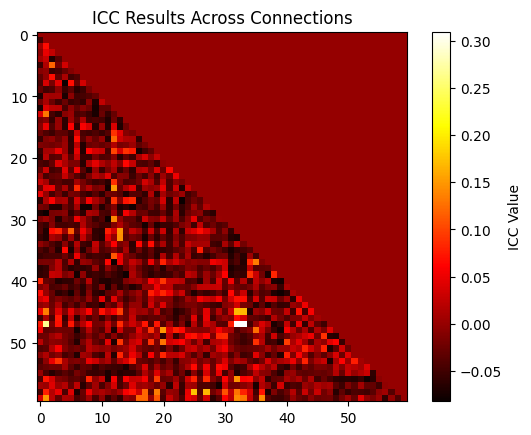

In [ ]:
import numpy as np
import pandas as pd
import pingouin as pg
import time

# Start Timer for Execution
start_time = time.time()

# Step 1: Simulate Input Data Information
print("### Step 1: Input Data Overview ###")
print(f"Input Data Type: {type(average_patients_valid_data)}")
print(f"Input Data Shape: {average_patients_valid_data.shape}")

n_patients, n_conditions, n_channels, _ = average_patients_valid_data.shape
print(f"Number of Patients: {n_patients}")
print(f"Number of Conditions: {n_conditions}")
print(f"Number of Channels: {n_channels}")

# Step 2: Extract Lower Triangle Indices (Excluding Diagonal)
print("\n### Step 2: Extracting Lower Triangle Indices ###")
lower_indices = np.tril_indices(n_channels, k=-1)
print(f"Total Connections in Lower Triangle: {len(lower_indices[0])}")

# Step 3: Flatten Lower Triangles Across Patients and Conditions
print("\n### Step 3: Flattening Lower Triangle Values ###")
lower_triangle_data = []
for patient in range(n_patients):
    for condition in range(n_conditions):
        matrix = average_patients_valid_data[patient, condition]
        lower_triangle = matrix[lower_indices]
        lower_triangle_data.append(lower_triangle)
lower_triangle_data = np.array(lower_triangle_data)
print(f"Flattened Data Shape: {lower_triangle_data.shape}")

# Step 4: Preparing DataFrame for ICC Calculation
print("\n### Step 4: Preparing Data for ICC ###")
n_connections = lower_triangle_data.shape[1]
patient_labels = np.repeat(np.arange(n_patients), n_conditions)
condition_labels = np.tile(np.arange(n_conditions), n_patients)

# Organize data into a DataFrame
data = {
    "Patient": np.repeat(np.arange(n_patients), n_conditions * n_connections),
    "Condition": np.tile(np.repeat(np.arange(n_conditions), n_connections), n_patients),
    "Connection": np.tile(np.arange(n_connections), n_patients * n_conditions),
    "Value": lower_triangle_data.flatten(),
}
icc_input = pd.DataFrame(data)
print(f"DataFrame Shape: {icc_input.shape}")
print(icc_input.head())

# Step 5: Calculate ICC for Each Connection
print("\n### Step 5: Calculating ICC for Each Connection ###")
icc_results = []
for conn in range(n_connections):
    subset = icc_input[icc_input["Connection"] == conn]
    icc = pg.intraclass_corr(
        data=subset, targets="Condition", raters="Patient", ratings="Value"
    )
    icc_results.append(icc["ICC"][2])  # ICC3 is commonly used for fixed raters

print(f"Number of Connections Calculated: {len(icc_results)}")

# Step 6: Map ICC Results Back to Lower Triangle Matrix
print("\n### Step 6: Mapping ICC Results to Matrix ###")
icc_results = np.array(icc_results)
icc_matrix = np.zeros((n_channels, n_channels))
icc_matrix[lower_indices] = icc_results

# Step 7: Summary and Execution Time
print("\n### Step 7: Execution Summary ###")
print(f"ICC Results Shape: {icc_matrix.shape}")
print(f"ICC Results Mean: {np.nanmean(icc_results):.4f}")
print(f"ICC Results Std: {np.nanstd(icc_results):.4f}")

end_time = time.time()
print(f"Execution Time: {end_time - start_time:.2f} seconds")

# Optional: Visualization of ICC Matrix (Lower Triangle)
import matplotlib.pyplot as plt

plt.imshow(icc_matrix, cmap="hot", interpolation="nearest")
plt.title("ICC Results Across Connections")
plt.colorbar(label="ICC Value")
plt.show()


The ICC results in your plot suggest a **low consistency** across connections, as indicated by the small or even negative ICC values. Here's a quick analysis and suggestions for next steps:

---

### **Analysis of Results**:
1. **Low ICC Values**:
   - Most values appear **close to 0 or negative**, meaning the connections across conditions lack reliability.
   - ICC values near zero imply that the variance **within conditions** is as high as (or higher than) the variance **between conditions**.
   - Negative ICC indicates poor reliability or insufficient variability across conditions.

2. **Sparse High Values**:
   - A few connections (small bright spots) show ICC > 0.15, indicating **slightly more consistent connections**.

---

### **Reasons for Low ICC**:
1. **High Variability Across Conditions**:
   - The connectivity matrices for different conditions are inconsistent for most connections.

2. **Insufficient Sample Size**:
   - You only have **13 patients**, which may reduce the statistical power for ICC calculation.

3. **Preprocessing Effects**:
   - If connectivity measures (e.g., EEG features) were not normalized or filtered correctly, this could introduce variability.

---

### **Next Steps**:
Here’s what you can do to further analyze and interpret these results:

1. **Inspect Connections with High ICC**:
   - Identify connections with ICC > 0.15 and print their indices:
     ```python
     high_icc_indices = np.where(icc_results > 0.15)
     print("Connections with High ICC:", high_icc_indices)
     ```

2. **Plot Distribution of ICC Values**:
   - Visualize the distribution of ICC values to see the overall reliability:
     ```python
     import seaborn as sns
     sns.histplot(icc_results, bins=30, kde=True)
     plt.title("Distribution of ICC Values")
     plt.xlabel("ICC Value")
     plt.ylabel("Frequency")
     plt.show()
     ```

3. **Filter Noisy Connections**:
   - Focus only on **consistent connections** with ICC > 0.1 or 0.15.

4. **Increase Sample Size**:
   - If possible, include more patients to improve reliability.

5. **Check Preprocessing Pipeline**:
   - Revisit how connectivity values were computed (e.g., filtering, normalization) to reduce noise across conditions.

6. **Alternative Methods**:
   - Use **Network-Based Statistics (NBS)** or graph theory metrics to identify clusters of reliable connections rather than individual ICC values.

---

Let me know if you'd like me to implement any of these steps or refine the analysis further! 🚀